In [2]:
pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.6 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.linear_model import Ridge
import torch
from torch import nn
from scipy.stats import ttest_rel
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from skopt import BayesSearchCV
from skopt.space import Integer, Real
from sklearn.model_selection import KFold
size_text =24
plt.rcParams.update({
    #'font.family': 'serif',
    #'text.usetex': False,  # Evita usar LaTeX
    'axes.titlesize': size_text,
    'xtick.labelsize': size_text,
    'ytick.labelsize': size_text,
    'legend.fontsize': size_text,
    'ytick.major.size': 2,
    'xtick.major.size': 2,
})

w = 10
h = 6

# Dataset

In [4]:
df = pd.read_csv("Case_2.csv")

X = df[['R', 'b']]
y = df['Fij']

df.shape

(40000, 3)

# Train - Test Set

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data scaling

In [6]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()


# Se ajusta solo con datos de entrenamiento
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

# Search for the best hyperparameters

## Grid search

In [ ]:
pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('ridge', Ridge())
])

# Rango de hiperparámetros a probar
param_grid = {
    'poly__degree': [2, 3, 4, 5, 6, 7, 8],
    'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 30, 100, 300]
}

# Grid search
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train_scaled)

print(f"Mejor combinación: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

Mejor combinación: {'poly__degree': 8, 'ridge__alpha': 0.01}


# Bayesian search

In [ ]:
pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('ridge', Ridge())
])

search_spaces = {
    'poly__degree': Integer(2, 8),
    'ridge__alpha': Real(1e-5, 1e5, prior='log-uniform')
}

opt = BayesSearchCV(
    estimator=pipeline,
    search_spaces=search_spaces,
    n_iter=30,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

opt.fit(X_train_scaled, y_train_scaled)
print(f"Best parameters (Bayes): {opt.best_params_}")
best_model_bayes = opt.best_estimator_

Best parameters (Bayes): OrderedDict([('poly__degree', 8), ('ridge__alpha', 0.012528683191355855)])


# Model training process

In [7]:
model = Pipeline([
    ('poly',  PolynomialFeatures(degree=8, include_bias=False)),
    ('ridge', Ridge(alpha=0.012528683191355855))
])


model.fit(X_train_scaled, y_train_scaled)

# Predicciones
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Measure execution time





In [8]:
import time


t0 = time.perf_counter()

model = Pipeline([
    ('poly',  PolynomialFeatures(degree=8, include_bias=False)),
    ('ridge', Ridge(alpha=0.012528683191355855))
])

model.fit(X_train_scaled, y_train_scaled)

t1 = time.perf_counter()
T_train_ridge_opt = t1 - t0
print(f"Tiempo entrenamiento (pipeline poly+ridge, alpha óptimo): {T_train_ridge_opt:.6f} s")

t2 = time.perf_counter()


y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

t3 = time.perf_counter()
T_pred_ridge_opt = t3 - t2
N_pred_opt = X_test_scaled.shape[0]
t_pred_ridge_opt = T_pred_ridge_opt / N_pred_opt

print(f"Tiempo predicción total (test, alpha óptimo): {T_pred_ridge_opt:.6f} s para {N_pred_opt} muestras")
print(f"Tiempo por predicción (alpha óptimo): {t_pred_ridge_opt:.8f} s/muestra")

Tiempo entrenamiento (pipeline poly+ridge, alpha óptimo): 0.300743 s
Tiempo predicción total (test, alpha óptimo): 0.037761 s para 8000 muestras
Tiempo por predicción (alpha óptimo): 0.00000472 s/muestra


In [9]:
t2 = time.perf_counter()
y_test_pred = model.predict(X_test_scaled)
t3 = time.perf_counter()

T_pred_ridge_test = t3 - t2
N_test = X_test_scaled.shape[0]
t_pred_ridge_test = T_pred_ridge_test / N_test

print(f"Tiempo predicción total (TEST, alpha óptimo): {T_pred_ridge_test:.6f} s para {N_test} muestras")
print(f"Tiempo por predicción (TEST, alpha óptimo): {t_pred_ridge_test:.8f} s/muestra")

Tiempo predicción total (TEST, alpha óptimo): 0.008408 s para 8000 muestras
Tiempo por predicción (TEST, alpha óptimo): 0.00000105 s/muestra


# Data inverse scaling

In [ ]:
y_train_real = scaler_y.inverse_transform(y_train_scaled.reshape(-1, 1)).ravel()
y_train_pred_real = scaler_y.inverse_transform(y_train_pred.reshape(-1, 1)).ravel()

y_test_real  = scaler_y.inverse_transform(y_test_scaled.reshape(-1,1)).ravel()
y_test_pred_real = scaler_y.inverse_transform(y_test_pred.reshape(-1,1)).ravel()

# Metrics

# Metrics for training

In [ ]:
mse_train = mean_squared_error(y_train_real,y_train_pred_real)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train_real, y_train_pred_real)
r2_train = r2_score(y_train_real, y_train_pred_real)

print(mse_train)
print(rmse_train)
print(mae_train)
print(r2_train)

0.0004101801345166528
0.020252904347689317
0.010929511278695394
0.9896124880989742


# Metrics for testing

In [ ]:
mse_test = mean_squared_error(y_test_real, y_test_pred_real )
rmse_test = np.sqrt(mse_test)
mae_test = mae_train = mean_absolute_error(y_test_real, y_test_pred_real )
r2_test = r2_score(y_test_real, y_test_pred_real )

print(mse_test)
print(rmse_test)
print(mae_test)
print(r2_test)

0.0003929292635086338
0.019822443429321063
0.010800145973762361
0.9901695709769642


In [ ]:
mape2 = np.mean(np.abs((y_test_real - y_test_pred_real) / y_test_real)) * 100
print(f"Error porcentual promedio (MAPE): {mape2:.2f}%")

Error porcentual promedio (MAPE): 1.97%


In [ ]:
Tolerance = 0.05  # 5%
Percentage = np.mean(np.abs((y_test_real - y_test_pred_real) / y_test_real) < tolerancia) * 100
print(f"Predicciones con menos de 5% de error: {Percentage:.2f}%")

Predicciones con menos de 5% de error: 91.20%


# Learning curves

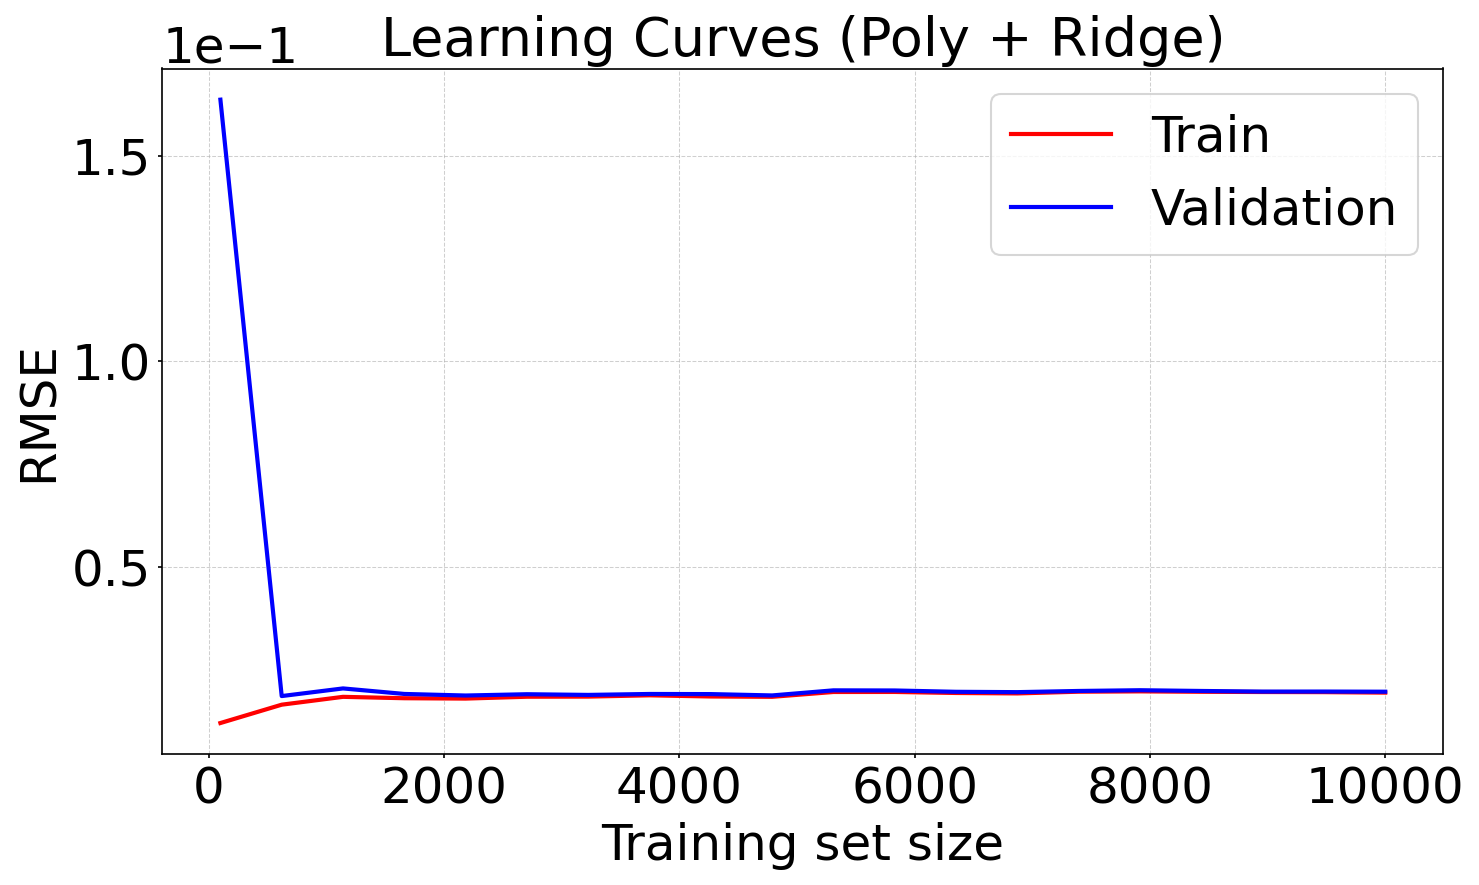

In [ ]:
def plot_learning_curves_poly_cv(X, y, grado, alpha, cv, size_text=size_text):
    # Asegurar que los índices están alineados
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)

    # 1. Usa solo el 80% de los datos para entrenamiento y validación
    X_sub, _, y_sub, _ = train_test_split(X, y, test_size=0.2, random_state=42)

    # 2. Tamaños crecientes de entrenamiento
    train_sizes = np.linspace(100, min(10000, len(X_sub)), 20, dtype=int)

    # Escalar X_sub completamente para todos los tamaños
    scaler_X = StandardScaler()
    X_sub_scaled = scaler_X.fit_transform(X_sub)

    train_errors, val_errors = [], []

    for m in train_sizes:
        X_sample = X_sub_scaled[:m]
        y_sample = y_sub[:m].to_numpy()

        # Validación cruzada manual
        kf = KFold(n_splits=cv, shuffle=True, random_state=42)
        train_rmse_fold = []
        val_rmse_fold = []

        for train_idx, val_idx in kf.split(X_sample):
            X_train_fold, X_val_fold = X_sample[train_idx], X_sample[val_idx]
            y_train_fold, y_val_fold = y_sample[train_idx], y_sample[val_idx]

            model = Pipeline([
                ('poly',  PolynomialFeatures(degree=grado, include_bias=False)),
                ('ridge', Ridge(alpha=alpha))
            ])

            model.fit(X_train_fold, y_train_fold)

            y_train_pred = model.predict(X_train_fold)
            y_val_pred   = model.predict(X_val_fold)

            train_rmse = np.sqrt(mean_squared_error(y_train_fold, y_train_pred))
            val_rmse   = np.sqrt(mean_squared_error(y_val_fold, y_val_pred))

            train_rmse_fold.append(train_rmse)
            val_rmse_fold.append(val_rmse)

        train_errors.append(np.mean(train_rmse_fold))
        val_errors.append(np.mean(val_rmse_fold))

    # 3. Graficar
    fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
    ax.plot(train_sizes, train_errors, "r-", linewidth=2, label="Train")
    ax.plot(train_sizes, val_errors, "b-", linewidth=2, label="Validation")

    ax.set_title("Learning Curves (Poly + Ridge)", fontsize=size_text + 2)
    ax.set_xlabel("Training set size", fontsize=size_text)
    ax.set_ylabel("RMSE", fontsize=size_text)
    ax.legend(fontsize=size_text)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

    plt.tight_layout()
    #plt.savefig("learning_curve_poly_cv.png", dpi=400, bbox_inches='tight')
    plt.savefig("C2_learning_curve_Ridge_cv.pdf", dpi=400, bbox_inches='tight')
    #plt.savefig("learning_curve_poly_cv.eps", dpi=400, bbox_inches='tight')
    plt.show()

# Este bloque no lo ejecutamos aquí porque necesitas tener X e y definidos.
plot_learning_curves_poly_cv(X, y, grado=8, alpha=0.01, cv=5)

# Predicted vs Actual Values

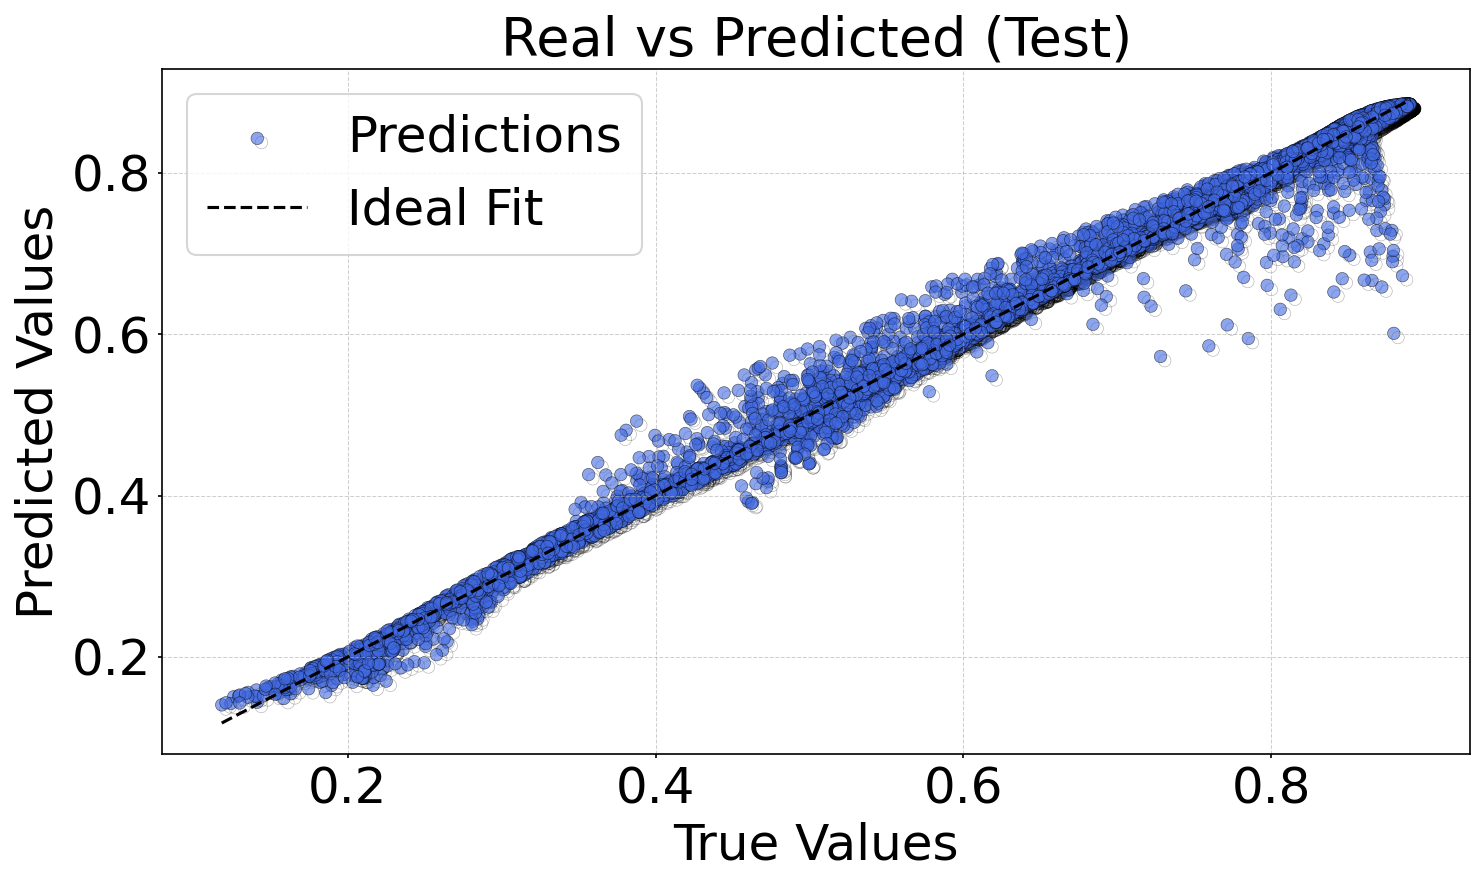

In [ ]:
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(w, h), dpi=150)


shadow = [pe.SimpleLineShadow(), pe.Normal()]


sc = ax.scatter(
    y_test_real, y_test_pred_real,
    alpha=0.6, color='royalblue',
    edgecolor='black', linewidth=0.3,
    label="Predictions"
)
sc.set_path_effects(shadow)


min_val = min(y_test_real.min(), y_test_pred_real.min())
max_val = max(y_test_real.max(), y_test_pred_real.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', label="Ideal Fit")


ax.set_title("Real vs Predicted (Test)", fontsize=size_text + 2)
ax.set_xlabel("True Values", fontsize=size_text)
ax.set_ylabel("Predicted Values", fontsize=size_text)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
ax.legend()


plt.tight_layout()
plt.savefig("C2_real_vs_pred_Ridge.pdf", dpi=400, bbox_inches='tight')
plt.show()